# Plot: pooled-model term importance

Loads the raw variance-partition fits from `1.variate_importance.ipynb` (`results/variate_importance/{organoid,single_cell}_variance_partition.parquet`) and plots the distribution of % variance explained per term.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(root_dir, "4.linear_modeling/figures/variate_importance")
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(root_dir, "4.linear_modeling/results/variate_importance")

TERM_ORDER = [
    "treatment",
    "patient",
    "treatment:patient",
    "cell_count",
    "organoid_count",
    "cell_per_organoid_count",
    "residual",
]
partition_dfs = {
    name: pd.read_parquet(results_path / f"{name}_variance_partition.parquet")
    for name in ["organoid", "single_cell"]
}

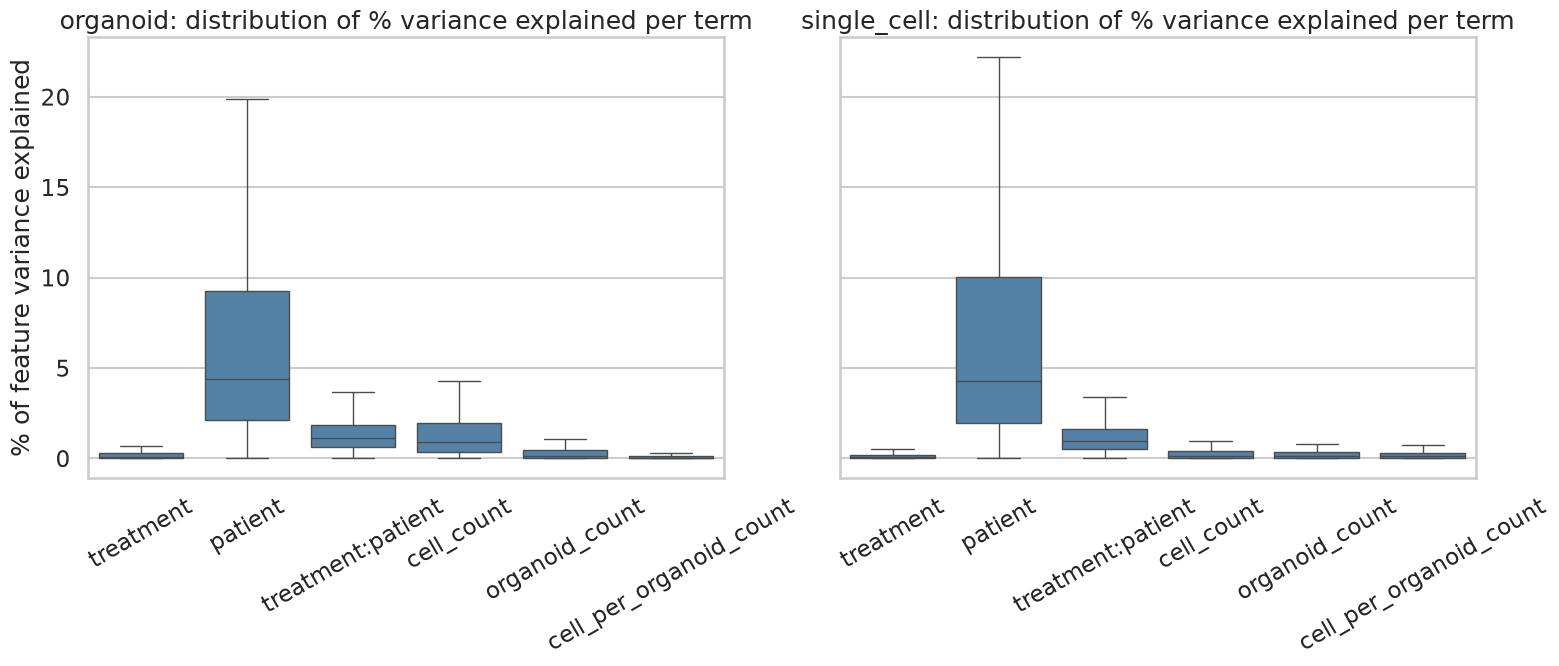

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (name, pdf) in zip(axes, partition_dfs.items()):
    plot_df = pdf[pdf["term"] != "residual"].copy()
    plot_df["term"] = pd.Categorical(
        plot_df["term"], categories=[t for t in TERM_ORDER if t != "residual"]
    )
    sns.boxplot(
        data=plot_df,
        x="term",
        y="pct_variance_explained",
        ax=ax,
        showfliers=False,
        color="steelblue",
    )
    ax.set_title(f"{name}: distribution of % variance explained per term")
    ax.set_xlabel("")
    ax.set_ylabel("% of feature variance explained")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(figures_path / "term_importance_boxplot.png", dpi=600, bbox_inches="tight")
plt.show()

`treatment:patient` (the interaction) captures the *heterogeneity* of drug response across patients — a large interaction term relative to the `treatment` main effect means the drug's effect genuinely differs by patient, not that the drug does nothing.